In [ ]:
import math
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils
import matplotlib.pyplot as plt

In [ ]:
# 1. device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

In [ ]:
# 2. hyperparameters
DATA_ROOT = "./data"
BATCH_SIZE = 128
EPOCHS = 150
LR = 1e-3
TIMESTEPS = 200            # Starting with 200，It can be changed to 500/1000
IMAGE_SIZE = 28
CHANNELS = 1
SAVE_DIR = "ddpm_unet_outputs"
os.makedirs(SAVE_DIR, exist_ok=True)


In [ ]:
# 3. dataset
transform = transforms.Compose([
    transforms.ToTensor(),                  # [0,1]
    transforms.Lambda(lambda x: x * 2 - 1) # [-1,1]
])

dataset = datasets.MNIST(
    root=DATA_ROOT,
    train=True,
    download=True,
    transform=transform
)

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

In [4]:


# 4. diffusion schedule
def linear_beta_schedule(timesteps, beta_start=1e-4, beta_end=0.06):
    return torch.linspace(beta_start, beta_end, timesteps)

betas = linear_beta_schedule(TIMESTEPS).to(device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)
alpha_bars_prev = F.pad(alpha_bars[:-1], (1, 0), value=1.0)

sqrt_alpha_bars = torch.sqrt(alpha_bars)
sqrt_one_minus_alpha_bars = torch.sqrt(1.0 - alpha_bars)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

posterior_variance = betas * (1.0 - alpha_bars_prev) / (1.0 - alpha_bars)

def extract(a, t, x_shape):
    """
    a: [T]
    t: [B]
    return: [B,1,1,1] for broadcasting
    """
    out = a.gather(0, t)
    return out.reshape(t.shape[0], *((1,) * (len(x_shape) - 1)))


# 5. time embedding
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        half_dim = self.dim // 2
        factor = math.log(10000) / max(half_dim - 1, 1)
        emb = torch.exp(torch.arange(half_dim, device=time.device) * -factor)
        emb = time[:, None].float() * emb[None, :]
        emb = torch.cat([emb.sin(), emb.cos()], dim=-1)
        return emb


# 6. building blocks
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_ch)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)

        if in_ch != out_ch:
            self.residual = nn.Conv2d(in_ch, out_ch, 1)
        else:
            self.residual = nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(x)
        h = self.norm1(h)
        h = F.silu(h)

        time_term = self.time_mlp(t_emb)[:, :, None, None]
        h = h + time_term

        h = self.conv2(h)
        h = self.norm2(h)
        h = F.silu(h)

        return h + self.residual(x)

class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.block = ConvBlock(in_ch, out_ch, time_emb_dim)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x, t_emb):
        h = self.block(x, t_emb)
        down = self.pool(h)
        return h, down

class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, time_emb_dim):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.block = ConvBlock(out_ch + skip_ch, out_ch, time_emb_dim)

    def forward(self, x, skip, t_emb):
        x = self.up(x)

        # Align the dimensions to prevent a 1-pixel error of 28x28 size during upsampling
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="nearest")

        x = torch.cat([x, skip], dim=1)
        x = self.block(x, t_emb)
        return x


# 7. small U-Net
class SmallUNet(nn.Module):
    def __init__(self, in_channels=1, base_channels=32, time_emb_dim=128):
        super().__init__()

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim),
        )

        self.init_conv = nn.Conv2d(in_channels, base_channels, 3, padding=1)

        self.down1 = DownBlock(base_channels, base_channels * 2, time_emb_dim)      # 28 -> 14
        self.down2 = DownBlock(base_channels * 2, base_channels * 4, time_emb_dim)  # 14 -> 7

        self.mid1 = ConvBlock(base_channels * 4, base_channels * 4, time_emb_dim)
        self.mid2 = ConvBlock(base_channels * 4, base_channels * 4, time_emb_dim)

        self.up1 = UpBlock(base_channels * 4, base_channels * 4, base_channels * 2, time_emb_dim)  # 7 -> 14
        self.up2 = UpBlock(base_channels * 2, base_channels * 2, base_channels, time_emb_dim)      # 14 -> 28

        self.final_block = ConvBlock(base_channels, base_channels, time_emb_dim)
        self.final_conv = nn.Conv2d(base_channels, in_channels, 1)

    def forward(self, x, t):
        t_emb = self.time_mlp(t)

        x = self.init_conv(x)

        skip1, x = self.down1(x, t_emb)
        skip2, x = self.down2(x, t_emb)

        x = self.mid1(x, t_emb)
        x = self.mid2(x, t_emb)

        x = self.up1(x, skip2, t_emb)
        x = self.up2(x, skip1, t_emb)

        x = self.final_block(x, t_emb)
        return self.final_conv(x)

model = SmallUNet(in_channels=1, base_channels=32, time_emb_dim=128).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)


# 8. forward diffusion q(x_t | x_0)
def q_sample(x_start, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x_start)

    sqrt_ab_t = extract(sqrt_alpha_bars, t, x_start.shape)
    sqrt_omb_t = extract(sqrt_one_minus_alpha_bars, t, x_start.shape)

    return sqrt_ab_t * x_start + sqrt_omb_t * noise


# 9. training loss
def p_losses(model, x_start, t):
    noise = torch.randn_like(x_start)
    x_noisy = q_sample(x_start, t, noise)
    predicted_noise = model(x_noisy, t)
    loss = F.mse_loss(predicted_noise, noise)
    return loss


# 10. reverse process
@torch.no_grad()
def p_sample(model, x, t):
    betas_t = extract(betas, t, x.shape)
    sqrt_one_minus_alpha_bars_t = extract(sqrt_one_minus_alpha_bars, t, x.shape)
    sqrt_recip_alphas_t = extract(sqrt_recip_alphas, t, x.shape)

    predicted_noise = model(x, t)

    model_mean = sqrt_recip_alphas_t * (
        x - betas_t * predicted_noise / sqrt_one_minus_alpha_bars_t
    )

    posterior_var_t = extract(posterior_variance, t, x.shape)

    noise = torch.randn_like(x)
    nonzero_mask = (t != 0).float().reshape(x.shape[0], *((1,) * (len(x.shape) - 1)))

    return model_mean + nonzero_mask * torch.sqrt(torch.clamp(posterior_var_t, min=1e-20)) * noise

@torch.no_grad()
def sample(model, n=16):
    model.eval()
    x = torch.randn((n, CHANNELS, IMAGE_SIZE, IMAGE_SIZE), device=device)

    for i in reversed(range(TIMESTEPS)):
        t = torch.full((n,), i, device=device, dtype=torch.long)
        x = p_sample(model, x, t)

    x = (x + 1) / 2
    x = torch.clamp(x, 0, 1)
    return x


# 11. training loop
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0

    for step, (x, _) in enumerate(dataloader):
        x = x.to(device)
        t = torch.randint(0, TIMESTEPS, (x.shape[0],), device=device).long()

        loss = p_losses(model, x, t)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if step % 100 == 0:
            print(f"Epoch {epoch+1}/{EPOCHS}, Step {step}, Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(dataloader)
    print(f"Epoch {epoch+1} done, avg loss = {avg_loss:.4f}")

    samples = sample(model, n=16).cpu()
    grid = utils.make_grid(samples, nrow=4)
    utils.save_image(grid, os.path.join(SAVE_DIR, f"epoch_{epoch+1}.png"))

print("Training finished.")




Using device: cuda
Epoch 1/150, Step 0, Loss: 1.1715
Epoch 1/150, Step 100, Loss: 0.0563
Epoch 1/150, Step 200, Loss: 0.0462
Epoch 1/150, Step 300, Loss: 0.0421
Epoch 1/150, Step 400, Loss: 0.0418
Epoch 1 done, avg loss = 0.0650
Epoch 2/150, Step 0, Loss: 0.0426
Epoch 2/150, Step 100, Loss: 0.0402
Epoch 2/150, Step 200, Loss: 0.0440
Epoch 2/150, Step 300, Loss: 0.0364
Epoch 2/150, Step 400, Loss: 0.0428
Epoch 2 done, avg loss = 0.0402
Epoch 3/150, Step 0, Loss: 0.0334
Epoch 3/150, Step 100, Loss: 0.0403
Epoch 3/150, Step 200, Loss: 0.0330
Epoch 3/150, Step 300, Loss: 0.0360
Epoch 3/150, Step 400, Loss: 0.0370
Epoch 3 done, avg loss = 0.0359
Epoch 4/150, Step 0, Loss: 0.0357
Epoch 4/150, Step 100, Loss: 0.0344
Epoch 4/150, Step 200, Loss: 0.0293
Epoch 4/150, Step 300, Loss: 0.0354
Epoch 4/150, Step 400, Loss: 0.0305
Epoch 4 done, avg loss = 0.0340
Epoch 5/150, Step 0, Loss: 0.0367
Epoch 5/150, Step 100, Loss: 0.0285
Epoch 5/150, Step 200, Loss: 0.0366
Epoch 5/150, Step 300, Loss: 0.0332

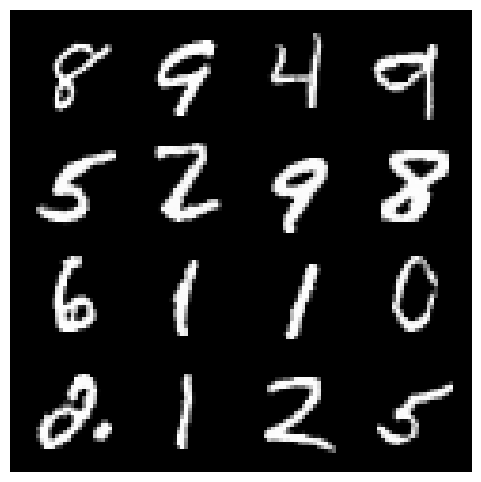

In [9]:
# 12. final sample show
samples = sample(model, n=16).cpu()
grid = utils.make_grid(samples, nrow=4).permute(1, 2, 0).squeeze()

plt.figure(figsize=(6, 6))
plt.imshow(grid, cmap="gray")
plt.axis("off")
plt.show()

Loss

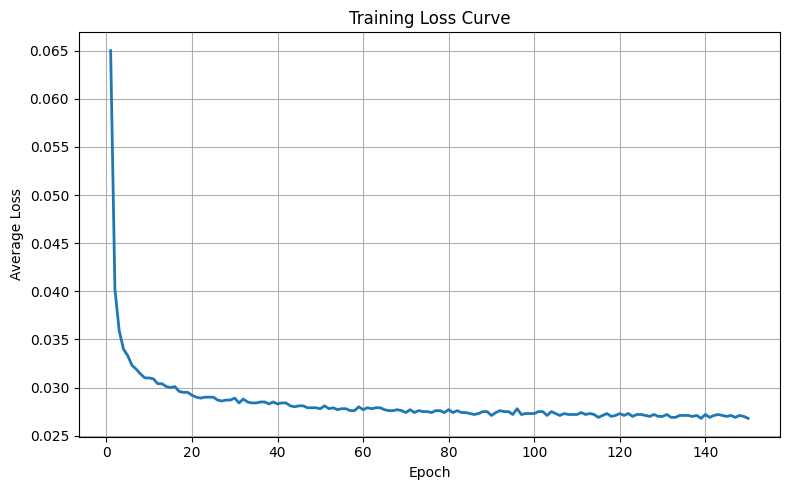

In [8]:
import matplotlib.pyplot as plt

loss_history = [
    0.0650, 0.0402, 0.0359, 0.0340, 0.0333, 0.0323, 0.0319, 0.0314, 0.0310, 0.0310,
    0.0309, 0.0304, 0.0304, 0.0301, 0.0300, 0.0301, 0.0296, 0.0295, 0.0295, 0.0292,
    0.0290, 0.0289, 0.0290, 0.0290, 0.0290, 0.0287, 0.0286, 0.0287, 0.0287, 0.0289,
    0.0284, 0.0288, 0.0285, 0.0284, 0.0284, 0.0285, 0.0285, 0.0283, 0.0285, 0.0283,
    0.0284, 0.0284, 0.0281, 0.0280, 0.0281, 0.0281, 0.0279, 0.0279, 0.0279, 0.0278,
    0.0281, 0.0278, 0.0279, 0.0277, 0.0278, 0.0278, 0.0276, 0.0276, 0.0280, 0.0277,
    0.0279, 0.0278, 0.0279, 0.0279, 0.0277, 0.0276, 0.0276, 0.0277, 0.0276, 0.0274,
    0.0277, 0.0274, 0.0276, 0.0275, 0.0275, 0.0274, 0.0276, 0.0276, 0.0274, 0.0277,
    0.0274, 0.0276, 0.0274, 0.0274, 0.0273, 0.0272, 0.0273, 0.0275, 0.0275, 0.0271,
    0.0274, 0.0276, 0.0275, 0.0275, 0.0272, 0.0278, 0.0272, 0.0273, 0.0273, 0.0273,
    0.0275, 0.0275, 0.0271, 0.0275, 0.0273, 0.0271, 0.0273, 0.0272, 0.0272, 0.0272,
    0.0274, 0.0272, 0.0273, 0.0272, 0.0269, 0.0271, 0.0273, 0.0270, 0.0271, 0.0273,
    0.0271, 0.0273, 0.0270, 0.0272, 0.0272, 0.0271, 0.0270, 0.0272, 0.0270, 0.0270,
    0.0272, 0.0269, 0.0269, 0.0271, 0.0271, 0.0271, 0.0270, 0.0271, 0.0268, 0.0272,
    0.0269, 0.0271, 0.0272, 0.0271, 0.0270, 0.0271, 0.0269, 0.0271, 0.0270, 0.0268
]

epochs = range(1, len(loss_history) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, loss_history, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.tight_layout()
plt.show()